<a href="https://colab.research.google.com/github/pdf1802/f1-race-replay/blob/feature%2Fdata-analysis/analysis/notebooks/race_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fastf1 pandas numpy matplotlib scikit-learn xgboost joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Paths ─────────────────────────────────────────────────────────────────────
# FastF1 cache: keeps downloaded session data so you don't re-download every run
# Models:       the .pkl files you saved in the earlier notebooks
CACHE_DIR = '/content/drive/MyDrive/f1_cache'
MODEL_DIR = '/content/drive/MyDrive/f1_models'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Cache dir : {CACHE_DIR}')
print(f'Model dir : {MODEL_DIR}')
print()

# List what models are available
models_found = os.listdir(MODEL_DIR) if os.path.exists(MODEL_DIR) else []
print(f'Models found: {models_found if models_found else "(empty — check the path)"}')

Mounted at /content/drive
Cache dir : /content/drive/MyDrive/f1_cache
Model dir : /content/drive/MyDrive/f1_models

Models found: ['lap_time_model.pkl', 'team_encoder.pkl', 'compound_map.json', 'overtaking_model.pkl']


In [3]:
import os, copy, fastf1, pandas as pd, numpy as np
import joblib, json, matplotlib.pyplot as plt, warnings
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache(CACHE_DIR)

LAP_MODEL    = joblib.load(f'{MODEL_DIR}/lap_time_model.pkl')
OVT_MODEL    = joblib.load(f'{MODEL_DIR}/overtaking_model.pkl')
TEAM_ENCODER = joblib.load(f'{MODEL_DIR}/team_encoder.pkl')

with open(f'{MODEL_DIR}/compound_map.json') as f:
    COMPOUND_MAP = json.load(f)
COMPOUND_NAMES = {v: k for k, v in COMPOUND_MAP.items()}

print('✅ All imports done')
print(f'   Lap model    : {type(LAP_MODEL).__name__}')
print(f'   OVT model    : {type(OVT_MODEL).__name__}')
print(f'   Compound map : {COMPOUND_MAP}')
print(f'\nTeams the encoder knows:')
for t in TEAM_ENCODER.classes_:
    print(f'   {t}')

✅ All imports done
   Lap model    : XGBRegressor
   OVT model    : XGBClassifier
   Compound map : {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}

Teams the encoder knows:
   Alfa Romeo
   AlphaTauri
   Alpine
   Aston Martin
   Ferrari
   Haas F1 Team
   Kick Sauber
   McLaren
   Mercedes
   RB
   Racing Bulls
   Red Bull Racing
   Williams


In [4]:
def encode_team(team_name: str) -> int:
    """Convert team name string to integer using the saved encoder."""
    try:
        return int(TEAM_ENCODER.transform([team_name])[0])
    except:
        return 0  # unknown team → silently defaults to 0

# ── Sanity check — run this every session ────────────────────────────────────
# If any team prints 0 AND it's not the first team alphabetically,
# it means FastF1 returns a different team name than what the encoder was trained on.
print('Team encoder check:')
for t in ['Red Bull Racing', 'Ferrari', 'Mercedes', 'McLaren', 'Aston Martin']:
    print(f'  {t:<25} → encoder value: {encode_team(t)}')

Team encoder check:
  Red Bull Racing           → encoder value: 11
  Ferrari                   → encoder value: 4
  Mercedes                  → encoder value: 8
  McLaren                   → encoder value: 7
  Aston Martin              → encoder value: 3


## Pace Factor Calculator

Derives team pace factors automatically from real FastF1 race data.
Averages across N races to avoid single-race outliers (DNFs, rain, SC).

- **Why N=5?** One race is anecdote. Five races is a trend.
- **Fastest team = 1.000.** Everyone else = their avg / fastest avg.
- A factor of **1.008** means ~0.8% slower = ~0.76s/lap slower at 95s base pace.

In [5]:
def calculate_pace_factors(season: int, n_races: int = 5) -> dict:
    """
    Calculate pace factors from first N races of a season.
    Returns {team_name: factor} relative to fastest team (= 1.000).
    """
    team_times  = {}
    team_counts = {}

    for round_num in range(1, n_races + 1):
        try:
            session = fastf1.get_session(season, round_num, 'R')
            session.load(telemetry=False)
            laps     = session.laps.pick_quicklaps()
            laps     = laps[laps['LapTime'].notna()]
            race_avg = laps.groupby('Team')['LapTime'].mean().dt.total_seconds()

            for team, avg_time in race_avg.items():
                team_times[team]  = team_times.get(team, 0) + avg_time
                team_counts[team] = team_counts.get(team, 0) + 1
            print(f'  Round {round_num} ✅')

        except Exception as e:
            print(f'  Round {round_num} skipped: {e}')

    # Require at least 2 races — one race could be a fluke (rain, DNF, SC)
    season_avg = {
        team: team_times[team] / team_counts[team]
        for team in team_times
        if team_counts[team] >= 2
    }
    fastest = min(season_avg.values())
    return {team: avg / fastest for team, avg in season_avg.items()}

print('✅ calculate_pace_factors() defined')

✅ calculate_pace_factors() defined


## Step 1 — Choose Season & Load Pace Factors

**This is your first input cell.** Change `SEASON` to simulate a different era:
- `2023` → Red Bull dominant (VER won 19/22 races)
- `2024` → McLaren / Red Bull / Ferrari close fight  
- `2025` → McLaren dominant

Run once per session. Data is cached on Drive after the first download.

In [6]:
SEASON = 2024   # ← change this

print(f'Loading {SEASON} pace factors from first 5 races...\n')
pace_factors = calculate_pace_factors(SEASON, n_races=5)

print(f'\n{SEASON} pace factors (fastest = 1.000):')
for team, factor in sorted(pace_factors.items(), key=lambda x: x[1]):
    gap_s = (factor - 1.0) * 95.0
    print(f'  {team:<25} {factor:.4f}  (+{gap_s:.2f}s/lap)')

Loading 2024 pace factors from first 5 races...



core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

  Round 1 ✅


req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req            INFO 	Using cached data for weather_data
INFO:fast

  Round 2 ✅


...

  Round 3 ✅


req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data h

  Round 4 ✅


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
INFO:fastf1.api:Fetching lap count data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api

  Round 5 ✅

2024 pace factors (fastest = 1.000):
  Red Bull Racing           1.0000  (+0.00s/lap)
  Ferrari                   1.0038  (+0.36s/lap)
  McLaren                   1.0052  (+0.49s/lap)
  Mercedes                  1.0083  (+0.79s/lap)
  Aston Martin              1.0095  (+0.90s/lap)
  Haas F1 Team              1.0162  (+1.54s/lap)
  Williams                  1.0169  (+1.61s/lap)
  Kick Sauber               1.0171  (+1.63s/lap)
  Alpine                    1.0173  (+1.64s/lap)
  RB                        1.0188  (+1.79s/lap)


## Step 2 — Load Real Grid from FastF1  *(v2 Feature 1)*

`get_real_grid()` replaces the hardcoded `STARTING_GRID` from v1.

**Why this matters:** v1 always simulated VER / LEC / SAI / PER / NOR / ALO regardless
of which race you picked. Bahrain 2024 had **RUS (Mercedes) in P3**, not Sainz.  
Every v1 simulation was based on a grid that never existed in real life.

**Design decisions:**
- `telemetry=False, laps=False, weather=False` → we only need `session.results`.  
  Full load = ~500MB. Results table = ~10KB. Never download what you don't need.
- `compound=0` (SOFT) for all top-6 → F1 regulations require top-10 qualifiers to  
  start on their Q2 tyre. Every top team runs Soft in Q2 to guarantee a Q3 place.
- `tyre_age=1` → fresh tyres at race start.
- `reset_index(drop=True)` after `sort_values()` → keeps loop indices clean.

In [7]:
def get_real_grid(season: int, round_num: int) -> list[dict]:
    """
    Load real qualifying order from FastF1.
    Returns top-6 as list of dicts compatible with simulate_race().
    Returns empty list on any error — caller must handle this.
    """
    try:
        session = fastf1.get_session(season, round_num, 'Q')
        session.load(telemetry=False, laps=False, weather=False)
        results = (session.results
                         .sort_values('Position')
                         .head(6)
                         .reset_index(drop=True))
        grid = []
        for _, row in results.iterrows():
            grid.append({
                'driver'  : row['Abbreviation'],
                'team'    : row['TeamName'],
                'position': int(row['Position']),
                'compound': 0,   # SOFT — Q3 tyre rule
                'tyre_age': 1,
            })
        return grid

    except Exception as e:
        print(f'⚠️  get_real_grid({season}, {round_num}) failed: {e}')
        return []

# ── Verification ──────────────────────────────────────────────────────────────
print('Testing get_real_grid(2024, 1) — Bahrain 2024 Qualifying\n')
test_grid = get_real_grid(2024, 1)

all_ok = True
for entry in test_grid:
    enc    = encode_team(entry['team'])
    flag   = '✅' if enc != 0 else '⚠️  encoder=0 — NAME MISMATCH'
    print(f"P{entry['position']}  {entry['driver']:<5}  {entry['team']:<25}  enc={enc}  {flag}")
    if enc == 0:
        all_ok = False

print()
if all_ok:
    print('✅ All teams encode correctly — safe to proceed')
else:
    print('⚠️  Fix: compare the team name above with TEAM_ENCODER.classes_ output in Cell 3')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]


Testing get_real_grid(2024, 1) — Bahrain 2024 Qualifying



req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']


P1  VER    Red Bull Racing            enc=11  ✅
P2  LEC    Ferrari                    enc=4  ✅
P3  RUS    Mercedes                   enc=8  ✅
P4  SAI    Ferrari                    enc=4  ✅
P5  PER    Red Bull Racing            enc=11  ✅
P6  ALO    Aston Martin               enc=3  ✅

✅ All teams encode correctly — safe to proceed


## Step 3 — Race Configuration

**This is your second input cell.** Change `ROUND_NUM` to pick a different race.

The grid is loaded automatically from FastF1. Strategies are auto-generated
at 30% and 60% of race distance — sensible defaults for a 1-stop race.

In [8]:
ROUND_NUM = 1   # ← race round number within the season (1–24)

RACE_CONFIG = {
    'circuit'         : f'{SEASON} Round {ROUND_NUM}',
    'total_laps'      : 57,
    'track_temp'      : 35.0,
    'air_temp'        : 28.0,
    'rainfall'        : 0,
    'sc_prob_per_lap' : 0.04,
    'pace_factors'    : pace_factors,
}

# Load real qualifying grid
real_grid = get_real_grid(SEASON, ROUND_NUM)
if not real_grid:
    raise RuntimeError(
        f'Could not load grid for {SEASON} Round {ROUND_NUM}. '
        'Check your Drive cache or try a different round.'
    )

# Auto-generate 1-stop strategies (works for any circuit length)
stop1 = int(RACE_CONFIG['total_laps'] * 0.30)   # ~lap 17 for Bahrain
stop2 = int(RACE_CONFIG['total_laps'] * 0.60)   # ~lap 34 for Bahrain

STRATEGIES = {
    entry['driver']: [(stop1, 1), (stop2, 2)]
    for entry in real_grid
}

print(f'✅ Grid loaded — {SEASON} Round {ROUND_NUM}')
print(f'   Strategy: stop at laps {stop1} (→ MEDIUM) and {stop2} (→ HARD)\n')
for entry in real_grid:
    print(f'   P{entry["position"]}  {entry["driver"]:<5}  {entry["team"]}')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '16', '63', '55', '11', '14', '4', '81', '44', '27', '22', '18', '23', '3', '20', '77', '24', '2', '31', '10']


✅ Grid loaded — 2024 Round 1
   Strategy: stop at laps 17 (→ MEDIUM) and 34 (→ HARD)

   P1  VER    Red Bull Racing
   P2  LEC    Ferrari
   P3  RUS    Mercedes
   P4  SAI    Ferrari
   P5  PER    Red Bull Racing
   P6  ALO    Aston Martin


## DriverState Dataclass

A **dataclass** is a typed, structured object for holding state.
Safer than a plain dict — wrong keys are caught immediately, and
methods like `next_pit()` live on the object itself.

**Design rule:** State holds data. Logic lives in functions.  
Never put simulation logic inside the dataclass.

In [10]:
@dataclass
class DriverState:
    driver:       str
    team_encoded: int
    team_name:    str
    position:     int
    compound:     int
    tyre_age:     int
    race_time:    float = 0.0
    laps_done:    int   = 0
    retired:      bool  = False
    strategy:     List[Tuple[int, int]] = field(default_factory=list)

    def next_pit(self) -> Optional[Tuple[int, int]]:
        """Next scheduled pit stop (lap, new_compound), or None if done."""
        upcoming = [(lap, comp) for lap, comp in self.strategy if lap > self.laps_done]
        return upcoming[0] if upcoming else None

    def __repr__(self):
        cname = {0: 'SOFT', 1: 'MEDIUM', 2: 'HARD'}.get(self.compound, '?')
        return (f'P{self.position} {self.driver} | '
                f'{cname} age {self.tyre_age} | '
                f'race time {self.race_time:.1f}s')

print('✅ DriverState defined')

✅ DriverState defined


In [11]:
# Build DriverState objects from the real grid
drivers = []
for entry in real_grid:
    ds = DriverState(
        driver       = entry['driver'],
        team_encoded = encode_team(entry['team']),
        team_name    = entry['team'],
        position     = entry['position'],
        compound     = entry['compound'],
        tyre_age     = entry['tyre_age'],
        strategy     = STRATEGIES[entry['driver']],
    )
    drivers.append(ds)

print('Starting grid:')
for d in drivers:
    print(f'  {d}')
    print(f'     next pit → {d.next_pit()}')

Starting grid:
  P1 VER | SOFT age 1 | race time 0.0s
     next pit → (17, 1)
  P2 LEC | SOFT age 1 | race time 0.0s
     next pit → (17, 1)
  P3 RUS | SOFT age 1 | race time 0.0s
     next pit → (17, 1)
  P4 SAI | SOFT age 1 | race time 0.0s
     next pit → (17, 1)
  P5 PER | SOFT age 1 | race time 0.0s
     next pit → (17, 1)
  P6 ALO | SOFT age 1 | race time 0.0s
     next pit → (17, 1)


## Lap Time Prediction

Calls the saved XGBoost model (Module 1) to predict `LapDelta` —
seconds above that driver's personal best. Added back to `BASE_LAPTIME`
to get an absolute lap time.

**Batch predict:** we call `predict()` once for ALL drivers per lap.  
1000 runs × 57 laps × 6 drivers = 342,000 prediction calls.  
Batching keeps this under 10 seconds total.

**Gaussian noise (σ=0.15s):** makes each Monte Carlo run slightly different.  
Without it every run produces identical results — not a simulation, just a calculation.

In [12]:
BASE_LAPTIME = 95.0   # Bahrain 2024 average racing lap ~95s

def predict_lap_time_batch(drivers: list, lap: int, config: dict) -> dict:
    """
    Predict lap times for ALL active drivers in one model call.
    Returns {driver_code: lap_time_seconds}.
    """
    active = [d for d in drivers if not d.retired]
    if not active:
        return {}

    rows = [{
        'CompoundEncoded' : d.compound,
        'TyreLife'        : d.tyre_age,
        'TeamEncoded'     : d.team_encoded,
        'LapNumber'       : lap,
        'TrackTemp'       : config['track_temp'],
        'AirTemp'         : config['air_temp'],
        'RainfallEncoded' : config['rainfall'],
    } for d in active]

    features = pd.DataFrame(rows)
    deltas   = LAP_MODEL.predict(features)
    factors  = np.array([config['pace_factors'].get(d.team_name, 1.0) for d in active])
    noise    = np.random.normal(0, 0.15, size=len(active))
    times    = (BASE_LAPTIME + deltas) * factors + noise

    return {d.driver: t for d, t in zip(active, times)}

print('✅ predict_lap_time_batch() defined')

✅ predict_lap_time_batch() defined


## Pit Stop Logic

Two things happen during a pit stop:
1. **Tyre change** — compound and `tyre_age` reset on the DriverState
2. **Time loss** — sampled from a normal distribution (~22-24s in Bahrain)  
   to reflect real variance between stops

No position changes here — that's handled by the overtake logic.  
Here we only handle **time and tyre state**.

In [13]:
PIT_LOSS_MEAN = 23.5   # seconds lost vs staying out (Bahrain 2024 avg)
PIT_LOSS_STD  = 0.8    # variance between individual stops

def apply_pit_stop(driver: DriverState, lap: int) -> tuple[bool, float]:
    """
    Check if driver pits this lap. If yes, execute it.
    Returns (did_pit, time_cost). time_cost = 0.0 if no stop this lap.
    """
    next_stop = driver.next_pit()
    if next_stop is None:
        return False, 0.0
    pit_lap, new_compound = next_stop
    if pit_lap != lap:
        return False, 0.0

    driver.compound = new_compound
    driver.tyre_age = 1
    return True, np.random.normal(PIT_LOSS_MEAN, PIT_LOSS_STD)

# ── Sanity check ──────────────────────────────────────────────────────────────
d0 = drivers[0]
print(f'=== PIT STOP CHECK — {d0.driver} ===')
print(f'Strategy: {d0.strategy}  |  Next pit: {d0.next_pit()}\n')

for lap in [stop1 - 1, stop1, stop1 + 1]:
    d_test = copy.deepcopy(d0)
    d_test.laps_done = lap - 1
    did_pit, cost = apply_pit_stop(d_test, lap)
    if did_pit:
        print(f'  Lap {lap:02d}: PIT ✅  cost={cost:.2f}s  new tyre={COMPOUND_NAMES[d_test.compound]}')
    else:
        print(f'  Lap {lap:02d}: no stop')

=== PIT STOP CHECK — VER ===
Strategy: [(17, 1), (34, 2)]  |  Next pit: (17, 1)

  Lap 16: no stop
  Lap 17: PIT ✅  cost=23.38s  new tyre=MEDIUM
  Lap 18: no stop


## Overtake Logic

Calls the saved Module 2 classifier to decide whether an overtake succeeds.

An attempt only happens when the following car is within DRS range (gap < 1.0s).  
The model returns a probability → we sample against it (`np.random.random() < prob`).  

This is the **Monte Carlo element**: the same scenario produces an overtake in  
run 600 but not run 601. Over 1000 runs, the probabilities converge.

In [14]:
DRS_WINDOW = 1.0   # seconds — DRS activation threshold

def check_overtakes(drivers: list) -> list:
    """
    For each consecutive pair in pace order, check if car behind overtakes.
    Max 1 position gain per driver per lap.
    Returns drivers sorted by updated position.
    """
    pace_order = sorted(drivers, key=lambda d: d.race_time)

    for i in range(1, len(pace_order)):
        car_behind = pace_order[i]
        car_ahead  = pace_order[i - 1]
        if car_behind.retired or car_ahead.retired:
            continue

        gap = car_behind.race_time - car_ahead.race_time
        if gap > DRS_WINDOW:
            continue

        features = pd.DataFrame([{
            'GapAhead'             : gap,
            'TyreDelta'            : car_ahead.tyre_age - car_behind.tyre_age,
            'CompoundEncoded'      : car_behind.compound,
            'CompoundAheadEncoded' : car_ahead.compound,
            'TyreLife'             : car_behind.tyre_age,
            'TyreLifeAhead'        : car_ahead.tyre_age,
            'LapNumber'            : car_behind.laps_done,
            'Position'             : car_behind.position,
        }])

        prob = OVT_MODEL.predict_proba(features)[0][1]
        if np.random.random() < prob:
            if car_ahead.position == car_behind.position - 1:
                car_behind.position, car_ahead.position = car_ahead.position, car_behind.position
                pace_order[i], pace_order[i - 1] = pace_order[i - 1], pace_order[i]

    return sorted(pace_order, key=lambda d: d.position)

# ── Sanity check ──────────────────────────────────────────────────────────────
# Set up P1 on old tyres, P2 on fresh tyres, 0.5s gap → overtake should happen often
d0_code, d1_code = drivers[0].driver, drivers[1].driver
test_d = copy.deepcopy(drivers)
test_d[0].race_time = 1000.0;  test_d[0].tyre_age = 25;  test_d[0].laps_done = 25
test_d[1].race_time = 1000.5;  test_d[1].tyre_age = 5;   test_d[1].laps_done = 25

wins = sum(1 for _ in range(20) if check_overtakes(copy.deepcopy(test_d))[0].driver == d1_code)
print(f'{d1_code} overtook {d0_code} in {wins}/20 trials ({wins*5}%)')
print(f'(gap=0.5s | {d0_code} tyre age=25 | {d1_code} tyre age=5)')

LEC overtook VER in 11/20 trials (55%)
(gap=0.5s | VER tyre age=25 | LEC tyre age=5)


## Full Lap Loop — `simulate_race()`

The core engine. Runs **one complete race** from lap 1 to lap N.

Each lap, for every driver:
1. `predict_lap_time_batch()` → lap time from the XGBoost model
2. Safety car check → random coin flip, adds 30s to everyone equally
3. `apply_pit_stop()` → pit if scheduled, add time cost
4. Update: `tyre_age += 1`, `laps_done += 1`, `race_time += lap_t`

After all drivers complete the lap:
5. `check_overtakes()` → green flag laps only

**Final standings = sort by `race_time`** (lowest cumulative time = winner).  
This function runs once. The Monte Carlo wrapper calls it 1,000 times.

In [15]:
SAFETY_CAR_DELTA = 30.0   # seconds added to everyone when SC is deployed

def simulate_race(config: dict, grid: list) -> list:
    """Simulate one full race. Returns drivers sorted by final position."""
    drivers = copy.deepcopy(grid)
    sc_active         = False
    sc_laps_remaining = 0

    for lap in range(1, config['total_laps'] + 1):
        # Safety car
        if sc_active:
            sc_laps_remaining -= 1
            if sc_laps_remaining <= 0:
                sc_active = False
        elif np.random.random() < config['sc_prob_per_lap']:
            sc_active         = True
            sc_laps_remaining = 4   # SC lasts ~4 laps in F1

        lap_times = predict_lap_time_batch(drivers, lap, config)

        for driver in drivers:
            if driver.retired:
                continue
            lap_time = lap_times[driver.driver]
            if sc_active:
                lap_time += SAFETY_CAR_DELTA
            did_pit, pit_cost = apply_pit_stop(driver, lap)
            if did_pit:
                lap_time += pit_cost
            driver.race_time += lap_time
            driver.tyre_age  += 1
            driver.laps_done  = lap

        if not sc_active:
            drivers = check_overtakes(drivers)

    # Final standings
    drivers = sorted(drivers, key=lambda d: d.race_time)
    for i, d in enumerate(drivers):
        d.position = i + 1
    return drivers

# ── One-race sanity check ─────────────────────────────────────────────────────
print('Running one race...\n')
result = simulate_race(RACE_CONFIG, drivers)
print(f'{"POS":<5} {"DRIVER":<8} {"RACE TIME":>12}  FINAL TYRE')
print('-' * 38)
for d in result:
    print(f'P{d.position:<4} {d.driver:<8} {d.race_time:>11.1f}s  {COMPOUND_NAMES.get(d.compound, "?")}')

Running one race...

POS   DRIVER      RACE TIME  FINAL TYRE
--------------------------------------
P1    PER           5533.9s  HARD
P2    VER           5534.9s  HARD
P3    LEC           5559.3s  HARD
P4    SAI           5561.0s  HARD
P5    RUS           5586.2s  HARD
P6    ALO           5613.3s  HARD


## Monte Carlo Wrapper

Calls `simulate_race()` N times and counts how often each driver wins.

- **n_runs=1000** → stable probabilities (±2-3% variance between wrapper runs)
- **n_runs=100** → faster for testing but probabilities will be noisy

All the complexity is inside `simulate_race()`. This wrapper just  
runs it many times and counts outcomes.

In [16]:
from collections import Counter

def monte_carlo(config: dict, grid: list, n_runs: int = 1000) -> dict:
    """
    Run simulate_race() n_runs times.
    Returns {driver: win_probability}, sorted highest first.
    """
    win_counts = Counter()
    for i in range(n_runs):
        result = simulate_race(config, grid)
        win_counts[result[0].driver] += 1
        if (i + 1) % 100 == 0:
            print(f'  {i + 1}/{n_runs} done...')
    return {d: c / n_runs for d, c in win_counts.most_common()}

# Speed optimisation — disable redundant XGBoost internal validation
LAP_MODEL.get_booster().set_param('nthread', 1)
import os; os.environ['OMP_NUM_THREADS'] = '1'
print('✅ monte_carlo() defined')

✅ monte_carlo() defined


In [17]:
print(f'🏎️  Running 1000 simulations — {SEASON} Round {ROUND_NUM}...\n')
probs = monte_carlo(RACE_CONFIG, drivers, n_runs=1000)

print('\n' + '=' * 45)
print(f'{"DRIVER":<10} {"WIN PROB":>10}  BAR')
print('=' * 45)
for driver, prob in probs.items():
    bar = '█' * int(prob * 40)
    print(f'{driver:<10} {prob*100:>9.1f}%  {bar}')
print('=' * 45)

🏎️  Running 1000 simulations — 2024 Round 1...

  100/1000 done...
  200/1000 done...
  300/1000 done...
  400/1000 done...
  500/1000 done...
  600/1000 done...
  700/1000 done...
  800/1000 done...
  900/1000 done...
  1000/1000 done...

DRIVER       WIN PROB  BAR
PER             50.9%  ████████████████████
VER             49.1%  ███████████████████


## Visualisation

Two charts:
1. **Win probability bar chart** — Monte Carlo summary across 1,000 races
2. **Position trace** — how positions evolved lap by lap in one example race

The colour palette is built dynamically from team names — works for any grid,  
not just the hardcoded 6 drivers from v1.

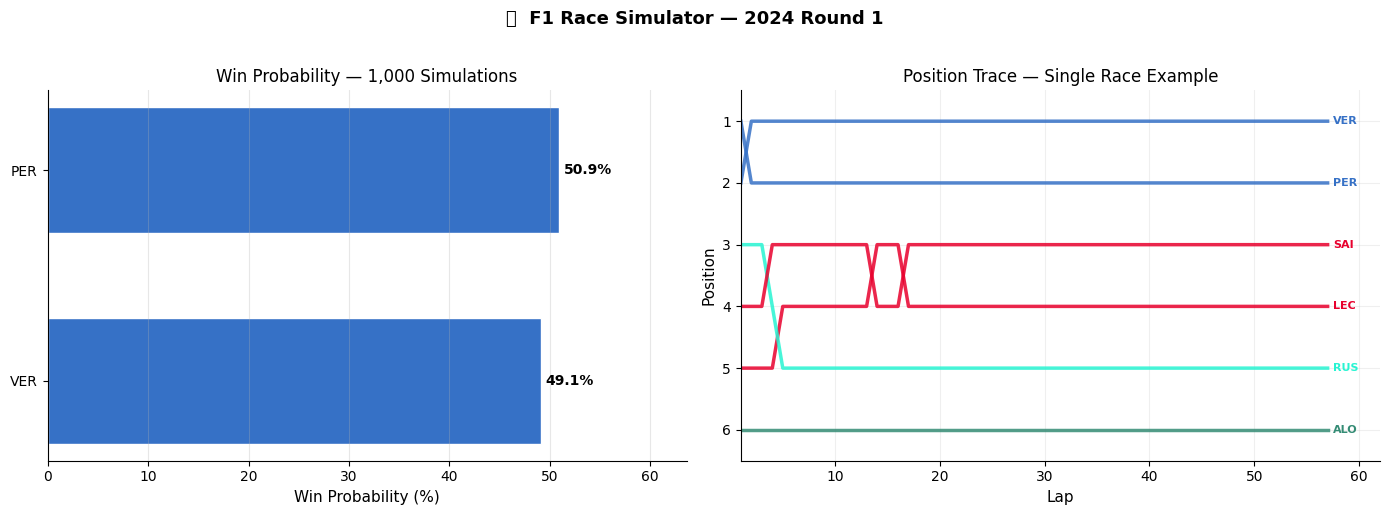

✅ Chart saved to your Drive as race_simulation.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np, copy

# ── Team colour palette ───────────────────────────────────────────────────────
# Keyed by TeamName (as FastF1 returns it) so it works for any grid automatically
TEAM_COLOURS = {
    'Red Bull Racing'  : '#3671C6',
    'Ferrari'          : '#E8002D',
    'Mercedes'         : '#27F4D2',
    'McLaren'          : '#FF8000',
    'Aston Martin'     : '#358C75',
    'Alpine'           : '#FF87BC',
    'Williams'         : '#64C4FF',
    'RB'               : '#6692FF',
    'Kick Sauber'      : '#52E252',
    'Haas F1 Team'     : '#B6BABD',
}

def driver_colour(driver_code: str) -> str:
    for entry in real_grid:
        if entry['driver'] == driver_code:
            return TEAM_COLOURS.get(entry['team'], '#888888')
    return '#888888'

# ── Build figure ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'🏎️  F1 Race Simulator — {SEASON} Round {ROUND_NUM}',
    fontsize=13, fontweight='bold', y=1.02
)

# Chart 1 — Win probability
d_list   = list(probs.keys())
win_pcts = [probs[d] * 100 for d in d_list]
colours  = [driver_colour(d) for d in d_list]

bars = ax1.barh(d_list[::-1], win_pcts[::-1],
                color=colours[::-1], edgecolor='white', height=0.6)
for bar, pct in zip(bars, win_pcts[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Win Probability (%)', fontsize=11)
ax1.set_title('Win Probability — 1,000 Simulations', fontsize=12)
ax1.set_xlim(0, max(win_pcts) * 1.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

# Chart 2 — Position trace (one example race)
trace_d           = copy.deepcopy(drivers)
sc_active         = False
sc_laps_remaining = 0
history           = {d.driver: [] for d in trace_d}

for lap in range(1, RACE_CONFIG['total_laps'] + 1):
    if sc_active:
        sc_laps_remaining -= 1
        if sc_laps_remaining <= 0:
            sc_active = False
    elif np.random.random() < RACE_CONFIG['sc_prob_per_lap']:
        sc_active = True; sc_laps_remaining = 4

    lts = predict_lap_time_batch(trace_d, lap, RACE_CONFIG)
    for d in trace_d:
        if d.retired: continue
        t = lts[d.driver]
        if sc_active: t += SAFETY_CAR_DELTA
        did_pit, cost = apply_pit_stop(d, lap)
        if did_pit: t += cost
        d.race_time += t; d.tyre_age += 1; d.laps_done = lap

    if not sc_active:
        trace_d = check_overtakes(trace_d)
    for i, d in enumerate(sorted(trace_d, key=lambda x: x.race_time)):
        history[d.driver].append(i + 1)

laps = list(range(1, RACE_CONFIG['total_laps'] + 1))
for drv, positions in history.items():
    c = driver_colour(drv)
    ax2.plot(laps, positions, color=c, linewidth=2.5, alpha=0.85)
    ax2.text(laps[-1] + 0.5, positions[-1], drv,
             va='center', fontsize=8, color=c, fontweight='bold')

ax2.set_xlabel('Lap', fontsize=11)
ax2.set_ylabel('Position', fontsize=11)
ax2.set_title('Position Trace — Single Race Example', fontsize=12)
ax2.set_ylim(len(drivers) + 0.5, 0.5)   # inverted: P1 at top
ax2.set_yticks(range(1, len(drivers) + 1))
ax2.set_xlim(1, RACE_CONFIG['total_laps'] + 5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/race_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to your Drive as race_simulation.png')